# 🤖 Notebook 03 — Text Preprocessing & Sentiment Analysis
## Early Warning System Krisis Pariwisata Bali

Notebook ini memproses:
1. Bali Hotel Review (semicolon-separated, multi-kolom)
2. Dataset of Digital Reviews in Tourism (hanya kolom review)
3. Text cleaning (lowercase, hapus URL, angka, tanda baca)
4. Deteksi bahasa (langdetect)
5. Sentiment analysis dengan Transformer (XLM-RoBERTa multilingual)
6. Agregasi sentimen bulanan

**Output:** `data/processed/monthly_sentiment.csv`

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

print('✅ Library dasar siap')

✅ Library dasar siap


## 1. Load Bali Hotel Review.csv

In [2]:
# ⚠️ File ini menggunakan SEMICOLON (;) sebagai pemisah, bukan koma
# Kolom: Location;Hotel;UserID;Title;Review;Rating;Value;Accessibility;Service;Room;Cleanliness;Sleep Quality

hotel_review = pd.read_csv(
    'data/raw/Bali Hotel Review.csv',
    sep=';',
    engine='python',
    on_bad_lines='skip'
)

print('Shape:', hotel_review.shape)
print('Columns:', hotel_review.columns.tolist())
print()
hotel_review.head(3)

Shape: (5798, 12)
Columns: ['Location', 'Hotel', 'UserID', 'Title', 'Review', 'Rating', 'Value', 'Accessibility', 'Service', 'Room', 'Cleanliness', 'Sleep Quality']



,Location,Hotel,UserID,Title,Review,Rating,Value,Accessibility,Service,Room,Cleanliness,Sleep Quality
0,Legian Kuta Bali,Merccure Bali Legian,Barry Sloan,Nice Hotek,Check in was smooth although my room wasn’t re...,4,0.0,0.0,1.0,0.0,0.0,0.0
1,Legian Kuta Bali,Merccure Bali Legian,u4ianoosa,"Perfect location, great Facilities",We thoroughly enjoyed our stay at Mercure Legi...,5,0.0,0.0,1.0,1.0,0.0,0.0
2,Legian Kuta Bali,Merccure Bali Legian,Phoenix G,A Fortnight at Mercure Legian Bali,Really the rating is 4.7 (I will attempt to ma...,5,0.0,1.0,1.0,0.0,0.0,0.0


In [3]:
# Ambil kolom yang relevan: Review, Rating, dan kolom numerik lainnya
# Cek nama kolom yang benar
cols_available = hotel_review.columns.tolist()
print('Kolom tersedia:', cols_available)

# Ambil kolom review dan rating (sesuaikan dengan nama kolom aktual)
# Kolom review biasanya: 'Review'
# Kolom rating: 'Rating'
review_col = [c for c in cols_available if 'review' in c.lower() or 'Review' in c]
rating_col = [c for c in cols_available if 'rating' in c.lower() or 'Rating' in c]

print('Review column:', review_col)
print('Rating column:', rating_col)

Kolom tersedia: ['Location', 'Hotel', 'UserID', 'Title', 'Review', 'Rating', 'Value', 'Accessibility', 'Service', 'Room', 'Cleanliness', 'Sleep Quality']
Review column: ['Review']
Rating column: ['Rating']


In [4]:
# Ambil kolom yang dibutuhkan
# Sesuaikan nama kolom dengan output di atas
review_col_name = review_col[0] if review_col else None
rating_col_name = rating_col[0] if rating_col else None

# Buat dataframe reviews
if review_col_name and rating_col_name:
    reviews = hotel_review[[review_col_name, rating_col_name]].copy()
    reviews.columns = ['review', 'rating']
elif review_col_name:
    reviews = hotel_review[[review_col_name]].copy()
    reviews.columns = ['review']
else:
    # Jika nama kolom berbeda, gunakan kolom ke-4 sebagai review
    reviews = hotel_review.iloc[:, [4, 5]].copy()
    reviews.columns = ['review', 'rating']

# Convert rating ke numerik
if 'rating' in reviews.columns:
    reviews['rating'] = pd.to_numeric(reviews['rating'], errors='coerce')

print('Shape reviews:', reviews.shape)
reviews.head(3)

Shape reviews: (5798, 2)


,review,rating
0,Check in was smooth although my room wasn’t re...,4
1,We thoroughly enjoyed our stay at Mercure Legi...,5
2,Really the rating is 4.7 (I will attempt to ma...,5


## 2. Load Dataset of Digital Reviews in Tourism

In [5]:
# File ini hanya punya 1 kolom: 'review'
digital_reviews = pd.read_csv(
    'data/raw/Dataset of Digital Reviews in Tourism - 2.csv',
    engine='python',
    on_bad_lines='skip'
)

print('Shape:', digital_reviews.shape)
print('Columns:', digital_reviews.columns.tolist())

# Rename jika perlu
if 'review' not in digital_reviews.columns:
    digital_reviews.columns = ['review']

digital_reviews.head(3)

Shape: (56448, 1)
Columns: ['review']


,review
0,An out of this world experience! Gita was an a...
1,What an amazing experience. Not only Orang-uta...
2,Good experience with the friendly staff at the...


## 3. Gabung Semua Dataset Review

In [6]:
# Gabung semua reviews menjadi 1 dataframe
# Tambahkan kolom sumber
reviews['source'] = 'bali_hotel'
digital_reviews_copy = digital_reviews[['review']].copy()
digital_reviews_copy['source'] = 'digital_tourism'

if 'rating' in reviews.columns:
    all_reviews = pd.concat([reviews, digital_reviews_copy], ignore_index=True)
else:
    all_reviews = pd.concat([reviews, digital_reviews_copy], ignore_index=True)

print('Total reviews gabungan:', len(all_reviews))
print('Per sumber:', all_reviews['source'].value_counts().to_dict())
all_reviews.head(3)

Total reviews gabungan: 62246
Per sumber: {'digital_tourism': 56448, 'bali_hotel': 5798}


,review,rating,source
0,Check in was smooth although my room wasn’t re...,4.0,bali_hotel
1,We thoroughly enjoyed our stay at Mercure Legi...,5.0,bali_hotel
2,Really the rating is 4.7 (I will attempt to ma...,5.0,bali_hotel


## 4. Text Cleaning

In [7]:
def clean_text(text):
    """
    Fungsi pembersih teks untuk review wisatawan.
    Kompatibel dengan teks multibahasa (EN, ID, ZH).
    """
    if pd.isna(text) or text == '':
        return ''
    
    text = str(text)
    
    # 1. Lowercase
    text = text.lower()
    
    # 2. Hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # 3. Hapus HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # 4. Hapus karakter khusus tapi pertahankan huruf, angka, spasi
    # Catatan: untuk teks Mandarin, kita pertahankan karakter unicode
    text = re.sub(r'[^\w\s\u4e00-\u9fff]', ' ', text)
    
    # 5. Hapus angka yang berdiri sendiri
    text = re.sub(r'\b\d+\b', '', text)
    
    # 6. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Terapkan cleaning
all_reviews['review_clean'] = all_reviews['review'].apply(clean_text)

# Hapus review kosong
all_reviews = all_reviews[all_reviews['review_clean'].str.len() > 10].copy()

# Hapus duplikat
all_reviews = all_reviews.drop_duplicates(subset=['review_clean']).reset_index(drop=True)

print('Setelah cleaning - Total reviews:', len(all_reviews))
print()
print('Contoh hasil cleaning:')
for i in range(3):
    print(f'  Original : {str(all_reviews["review"].iloc[i])[:80]}')
    print(f'  Cleaned  : {str(all_reviews["review_clean"].iloc[i])[:80]}')
    print()

Setelah cleaning - Total reviews: 61419

Contoh hasil cleaning:
  Original : Check in was smooth although my room wasn’t ready at 5pm, I was due to arrive at
  Cleaned  : check in was smooth although my room wasn t ready at 5pm i was due to arrive at 

  Original : We thoroughly enjoyed our stay at Mercure Legian, with a fantastic room with hug
  Cleaned  : we thoroughly enjoyed our stay at mercure legian with a fantastic room with huge

  Original : Really the rating is 4.7 (I will attempt to make this review short) Mercure is c
  Cleaned  : really the rating is i will attempt to make this review short mercure is conveni



## 5. Deteksi Bahasa

In [8]:
from langdetect import detect, LangDetectException

def detect_language(text):
    """Deteksi bahasa teks. Return 'unknown' jika gagal."""
    try:
        if len(str(text).strip()) < 10:
            return 'unknown'
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

# Deteksi bahasa (ini mungkin butuh beberapa menit untuk dataset besar)
print('Mendeteksi bahasa... (mungkin butuh beberapa menit)')
all_reviews['language'] = all_reviews['review_clean'].apply(detect_language)

# Ringkasan distribusi bahasa
lang_dist = all_reviews['language'].value_counts().head(10)
print('\nDistribusi Bahasa:')
print(lang_dist.to_string())

# Filter bahasa yang relevan: EN, ID, ZH (sesuai proyek)
target_languages = ['en', 'id', 'zh-cn', 'zh-tw', 'ms']
print(f'\nReviews dengan bahasa target {target_languages}: {all_reviews[all_reviews["language"].isin(target_languages)].shape[0]}')

Mendeteksi bahasa... (mungkin butuh beberapa menit)

Distribusi Bahasa:
language
en    61396
fr        4
es        3
id        3
ja        3
ru        2
tr        2
pt        1
de        1
fi        1

Reviews dengan bahasa target ['en', 'id', 'zh-cn', 'zh-tw', 'ms']: 61399


## 6. Sentiment Analysis dengan Transformer

Menggunakan **XLM-RoBERTa** yang mendukung analisis sentimen multibahasa (EN, ID, ZH).

⚠️ **Model ini akan download sekitar 500MB pertama kali dijalankan.**
Pastikan koneksi internet aktif.

In [9]:
from transformers import pipeline
import torch

# Cek apakah GPU tersedia
device = 0 if torch.cuda.is_available() else -1
print(f'Device: {"GPU" if device == 0 else "CPU"}')

# Load model XLM-RoBERTa untuk sentimen multibahasa
# Model ini support: EN, ID, ZH, dan 100+ bahasa lainnya
print('Loading model sentiment analysis...')
sentiment_analyzer = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-xlm-roberta-base-sentiment',
    device=device,
    max_length=512,
    truncation=True
)
print('✅ Model berhasil dimuat!')

Device: GPU
Loading model sentiment analysis...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model berhasil dimuat!


In [10]:
# Test model dengan contoh teks
test_texts = [
    'This hotel is amazing! Great service and beautiful view.',  # EN positif
    'Pelayanannya sangat buruk dan kamarnya kotor sekali.',       # ID negatif
    'Great location but the food was just okay.',                  # EN netral
]

print('Test Sentiment Analysis:')
for text in test_texts:
    result = sentiment_analyzer(text[:512])[0]
    print(f'  Teks  : {text[:60]}')
    print(f'  Hasil : {result["label"]} (score: {result["score"]:.3f})')
    print()

Test Sentiment Analysis:
  Teks  : This hotel is amazing! Great service and beautiful view.
  Hasil : positive (score: 0.942)

  Teks  : Pelayanannya sangat buruk dan kamarnya kotor sekali.
  Hasil : negative (score: 0.950)

  Teks  : Great location but the food was just okay.
  Hasil : positive (score: 0.843)



In [11]:
def get_sentiment_score(text):
    """
    Ambil skor sentimen dari teks.
    Return: float antara -1 (sangat negatif) sampai 1 (sangat positif)
    """
    try:
        text_clean = str(text)[:512]  # limit token
        if len(text_clean.strip()) < 5:
            return 0.0
        
        result = sentiment_analyzer(text_clean)[0]
        label = result['label'].lower()
        score = result['score']
        
        # Konversi ke skala -1 sampai 1
        if 'positive' in label or label == 'pos':
            return score          # positif
        elif 'negative' in label or label == 'neg':
            return -score         # negatif
        else:
            return 0.0            # netral
    except Exception:
        return 0.0

def get_sentiment_label(score):
    """Konversi skor ke label."""
    if score > 0.1:
        return 'positive'
    elif score < -0.1:
        return 'negative'
    else:
        return 'neutral'

print('Fungsi sentiment siap!')
print('Contoh:')
print('  Score:', get_sentiment_score('This hotel is terrible and the staff is rude'))

Fungsi sentiment siap!
Contoh:
  Score: -0.961677074432373


In [12]:
# ✅ Proses SEMUA reviews dengan batch processing (jauh lebih cepat di GPU)
print(f'Total reviews: {len(all_reviews)} baris')

reviews_sample = all_reviews.copy()

print(f'Memproses {len(reviews_sample)} reviews...')

# Batch processing — lebih cepat dibanding .apply()
BATCH_SIZE = 32

# Ambil semua teks sebagai list
texts = reviews_sample["review_clean"].fillna("").astype(str).tolist()

# Minimal panjang teks
texts = [t[:512] if len(t) >= 5 else "neutral" for t in texts]

# Jalankan batch inference
print(f"Menjalankan batch inference (batch_size={BATCH_SIZE})...")

results = sentiment_analyzer(
    texts,
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=512
)

# Konversi hasil ke skor -1 sampai 1
def result_to_score(r):
    label = r["label"].lower()
    score = r["score"]

    if "positive" in label or label == "pos":
        return score

    elif "negative" in label or label == "neg":
        return -score

    else:
        return 0.0


reviews_sample["sentiment_score"] = [
    result_to_score(r) for r in results
]

reviews_sample["sentiment_label"] = reviews_sample[
    "sentiment_score"
].apply(get_sentiment_label)

print("\n✅ Sentiment analysis selesai!")

print("\nDistribusi sentimen:")
print(
    reviews_sample["sentiment_label"]
    .value_counts()
    .to_string()
)

print(
    f"\nRata-rata skor: "
    f"{reviews_sample['sentiment_score'].mean():.3f}"
)

print(f"Total diproses: {len(reviews_sample)} reviews")

Total reviews: 61419 baris
Memproses 61419 reviews...
Menjalankan batch inference (batch_size=32)...

✅ Sentiment analysis selesai!

Distribusi sentimen:
sentiment_label
positive    38795
negative    17938
neutral      4686

Rata-rata skor: 0.228
Total diproses: 61419 reviews


In [13]:
# Simpan hasil sentiment
reviews_sample.to_csv('data/processed/reviews_with_sentiment.csv', index=False)
print('✅ reviews_with_sentiment.csv disimpan')

reviews_sample[['review_clean', 'language', 'sentiment_score', 'sentiment_label']].head(5)

✅ reviews_with_sentiment.csv disimpan


,review_clean,language,sentiment_score,sentiment_label
0,check in was smooth although my room wasn t re...,en,0.481530,positive
1,we thoroughly enjoyed our stay at mercure legi...,en,0.825768,positive
2,really the rating is i will attempt to make th...,en,0.000000,neutral
3,first time travelling to bali with our year ol...,en,0.818119,positive
4,very nice want to come back again kids enjoyed...,en,0.810524,positive


## 7. Sentimen Berdasarkan Rating (Jika Ada)

Untuk Bali_Hotel_Review.csv yang punya kolom rating, kita bisa validasi sentimen transformer dengan rating aktual.

In [14]:
if 'rating' in reviews_sample.columns:
    # Analisis korelasi rating vs sentiment score
    hotel_only = reviews_sample[reviews_sample['source'] == 'bali_hotel'].dropna(subset=['rating'])
    
    if len(hotel_only) > 0:
        corr = hotel_only['rating'].corr(hotel_only['sentiment_score'])
        print(f'Korelasi Rating vs Sentiment Score: {corr:.3f}')
        
        # Distribusi sentimen per rating
        print('\nRata-rata sentiment score per rating:')
        print(hotel_only.groupby('rating')['sentiment_score'].mean().round(3).to_string())
else:
    print('Kolom rating tidak tersedia di dataset ini.')

Korelasi Rating vs Sentiment Score: 0.357

Rata-rata sentiment score per rating:
rating
2.0   -0.918
3.0   -0.021
4.0    0.394
5.0    0.669


## 8. Agregasi Sentimen Bulanan

✅ **Dataset `merged_all_hotels.xlsx` memiliki kolom tanggal** — sentimen sekarang bisa diagregasi per bulan!
Ini menyelesaikan masalah *static sentiment* yang sebelumnya membuat `crisis_component_sentiment` bernilai konstan.

In [15]:
# ✅ PENDEKATAN BARU: Monthly Sentiment Aggregation (karena sudah ada tanggal)
# Hitung sentimen per bulan dari reviews yang punya tanggal

# Ambil reviews yang punya tanggal (merged_hotels)
reviews_with_date = reviews_sample[reviews_sample['date'].notna()].copy()
reviews_with_date['month'] = pd.to_datetime(reviews_with_date['date']).dt.to_period('M')

# Agregasi per bulan
monthly_sentiment = reviews_with_date.groupby('month').agg(
    avg_sentiment   = ('sentiment_score', 'mean'),
    pct_positive    = ('sentiment_label', lambda x: (x == 'positive').mean() * 100),
    pct_negative    = ('sentiment_label', lambda x: (x == 'negative').mean() * 100),
    pct_neutral     = ('sentiment_label', lambda x: (x == 'neutral').mean() * 100),
    review_count    = ('sentiment_score', 'count'),
    avg_rating      = ('rating', 'mean')
).reset_index()

monthly_sentiment['month'] = monthly_sentiment['month'].astype(str)

print('=== Monthly Sentiment Coverage ===')
print(f'Bulan dengan data: {len(monthly_sentiment)}')
print(f'Rentang: {monthly_sentiment["month"].min()} → {monthly_sentiment["month"].max()}')
print()
print('Sample 5 bulan terakhir:')
print(monthly_sentiment.tail(5).round(3).to_string())
print()

# Statistik global (tetap dihitung sebagai fallback untuk bulan tanpa data)
overall_sentiment = {
    'avg_sentiment':  reviews_sample['sentiment_score'].mean(),
    'pct_positive':   (reviews_sample['sentiment_label'] == 'positive').mean() * 100,
    'pct_negative':   (reviews_sample['sentiment_label'] == 'negative').mean() * 100,
    'pct_neutral':    (reviews_sample['sentiment_label'] == 'neutral').mean() * 100,
    'total_reviews':  len(reviews_sample)
}
print('=== Statistik Global (fallback) ===')
for k, v in overall_sentiment.items():
    print(f'  {k}: {v:.2f}' if isinstance(v, float) else f'  {k}: {v}')

KeyError: 'date'

In [ ]:
# Simpan monthly_sentiment.csv — dipakai di NB04 sebagai fitur time-series
monthly_sentiment.to_csv('data/processed/monthly_sentiment.csv', index=False)

# Simpan juga sentiment_stats.csv (nilai global sebagai fallback)
sentiment_stats = pd.DataFrame([overall_sentiment])
sentiment_stats.to_csv('data/processed/sentiment_stats.csv', index=False)

# Simpan semua reviews dengan sentiment
save_cols = ['review_clean', 'language', 'sentiment_score', 'sentiment_label', 'source']
if 'date' in reviews_sample.columns:
    save_cols = ['date'] + save_cols
reviews_sample[save_cols].to_csv('data/processed/all_reviews_sentiment.csv', index=False)

print('✅ monthly_sentiment.csv disimpan  ← BARU: sentimen per bulan (bervariasi!)')
print('✅ sentiment_stats.csv disimpan    ← fallback: sentimen global')
print('✅ all_reviews_sentiment.csv disimpan')
print()
print('Kolom monthly_sentiment:')
print(monthly_sentiment.columns.tolist())
print()
print('Langkah selanjutnya:')
print('  → NB04 akan merge monthly_sentiment berdasarkan kolom month')
print('  → crisis_component_sentiment sekarang bervariasi per bulan!')

## 9. Analisis Sentimen per Bahasa

In [ ]:
# Analisis sentimen berdasarkan bahasa
lang_sentiment = reviews_sample.groupby('language').agg(
    total=('sentiment_score', 'count'),
    avg_score=('sentiment_score', 'mean'),
    pct_positive=('sentiment_label', lambda x: (x == 'positive').mean() * 100),
    pct_negative=('sentiment_label', lambda x: (x == 'negative').mean() * 100)
).round(2)

# Sort berdasarkan total terbanyak
lang_sentiment = lang_sentiment.sort_values('total', ascending=False)

print('=== Analisis Sentimen per Bahasa ===')
print(lang_sentiment.head(10).to_string())

=== Analisis Sentimen per Bahasa ===
          total  avg_score  pct_positive  pct_negative
language                                              
en        61398       0.23         63.17         29.21
id            4       0.20         75.00         25.00
es            3      -0.20         33.33         33.33
ru            3       0.22         33.33          0.00
ja            3       0.57         66.67          0.00
tr            2      -0.08         50.00         50.00
fr            2      -0.28         50.00         50.00
de            1       0.72        100.00          0.00
cs            1       0.85        100.00          0.00
fi            1       0.71        100.00          0.00


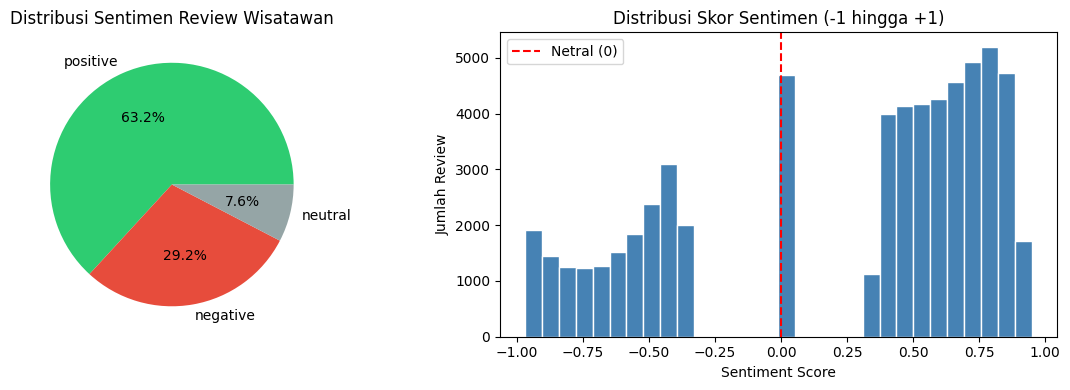

✅ Plot disimpan ke data/processed/sentiment_distribution.png


In [ ]:
import matplotlib.pyplot as plt

# Visualisasi distribusi sentimen
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart distribusi label
label_counts = reviews_sample['sentiment_label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[0].pie(label_counts.values, labels=label_counts.index, colors=colors, autopct='%1.1f%%')
axes[0].set_title('Distribusi Sentimen Review Wisatawan')

# Histogram skor sentimen
axes[1].hist(reviews_sample['sentiment_score'], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', label='Netral (0)')
axes[1].set_title('Distribusi Skor Sentimen (-1 hingga +1)')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Jumlah Review')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/processed/sentiment_distribution.png', dpi=150)
plt.show()
print('✅ Plot disimpan ke data/processed/sentiment_distribution.png')